In [43]:
#Set working directory
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

In [44]:
#Check the content of the geojson file
import geopandas as gpd
gdf = gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")

print(gdf.head())
print(gdf.columns)
print(gdf.geometry)

  id  objectType                             classification  isLocked  \
0  0  annotation  { "name": "Tubules", "colorRGB": -65536 }     False   
1  1  annotation  { "name": "Tubules", "colorRGB": -65536 }     False   
2  2  annotation  { "name": "Tubules", "colorRGB": -65536 }     False   
3  3  annotation  { "name": "Tubules", "colorRGB": -65536 }     False   
4  4  annotation  { "name": "Tubules", "colorRGB": -65536 }     False   

                                        measurements  \
0  [ { "name": "Confidence", "value": 0.948999999...   
1  [ { "name": "Confidence", "value": 0.957300000...   
2  [ { "name": "Confidence", "value": 0.920499999...   
3  [ { "name": "Confidence", "value": 0.896900000...   
4  [ { "name": "Confidence", "value": 0.918200000...   

                                            geometry  
0  POLYGON ((11134 7300, 11125 7296.5, 11123 7292...  
1  POLYGON ((10815 6839.5, 10821.79 6840.84, 1083...  
2  POLYGON ((20305 3847.99, 20303 3845.99, 20297 ...  
3  P

<Axes: >

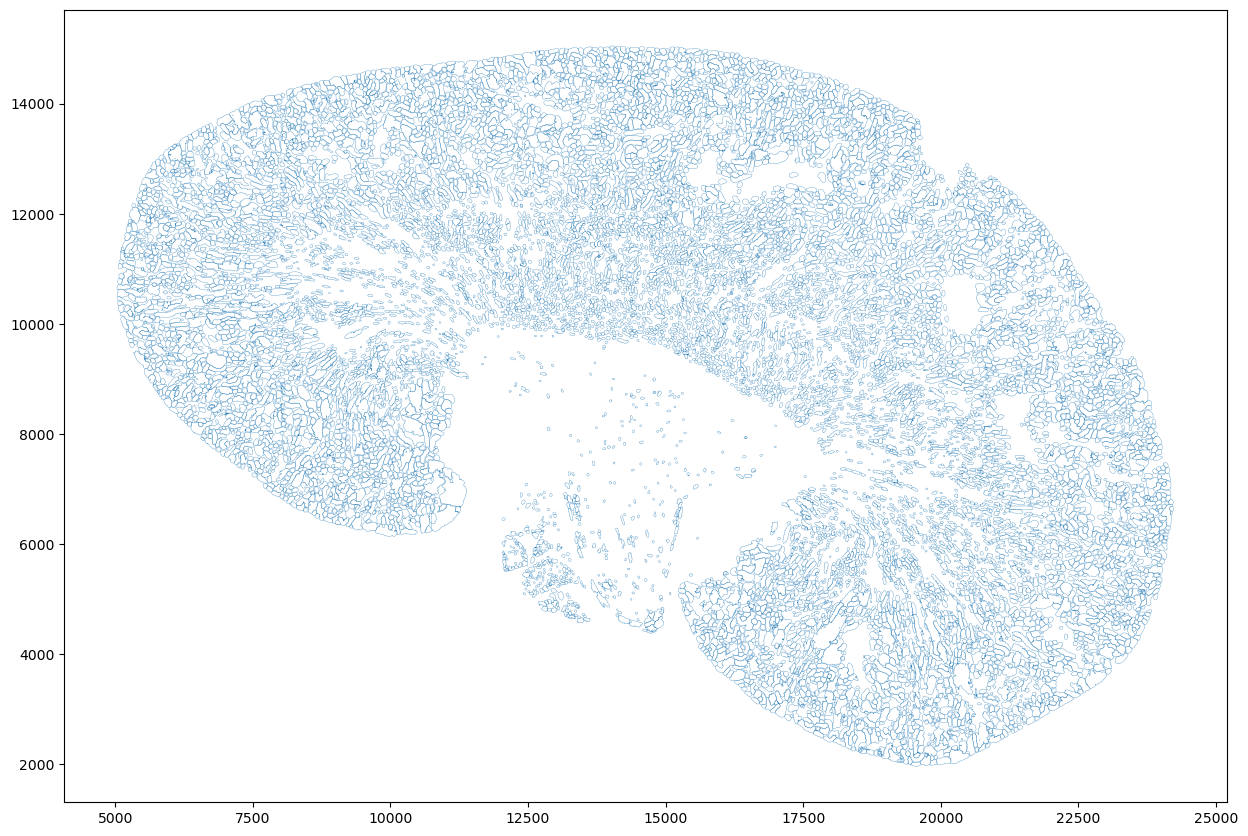

In [45]:
#To visualize all the instances of proximal tubules within the geojson files:
gdf = gdf.set_crs(None, allow_override=True)
gdf.boundary.plot(figsize=(15,15), linewidth=0.2)

<Axes: >

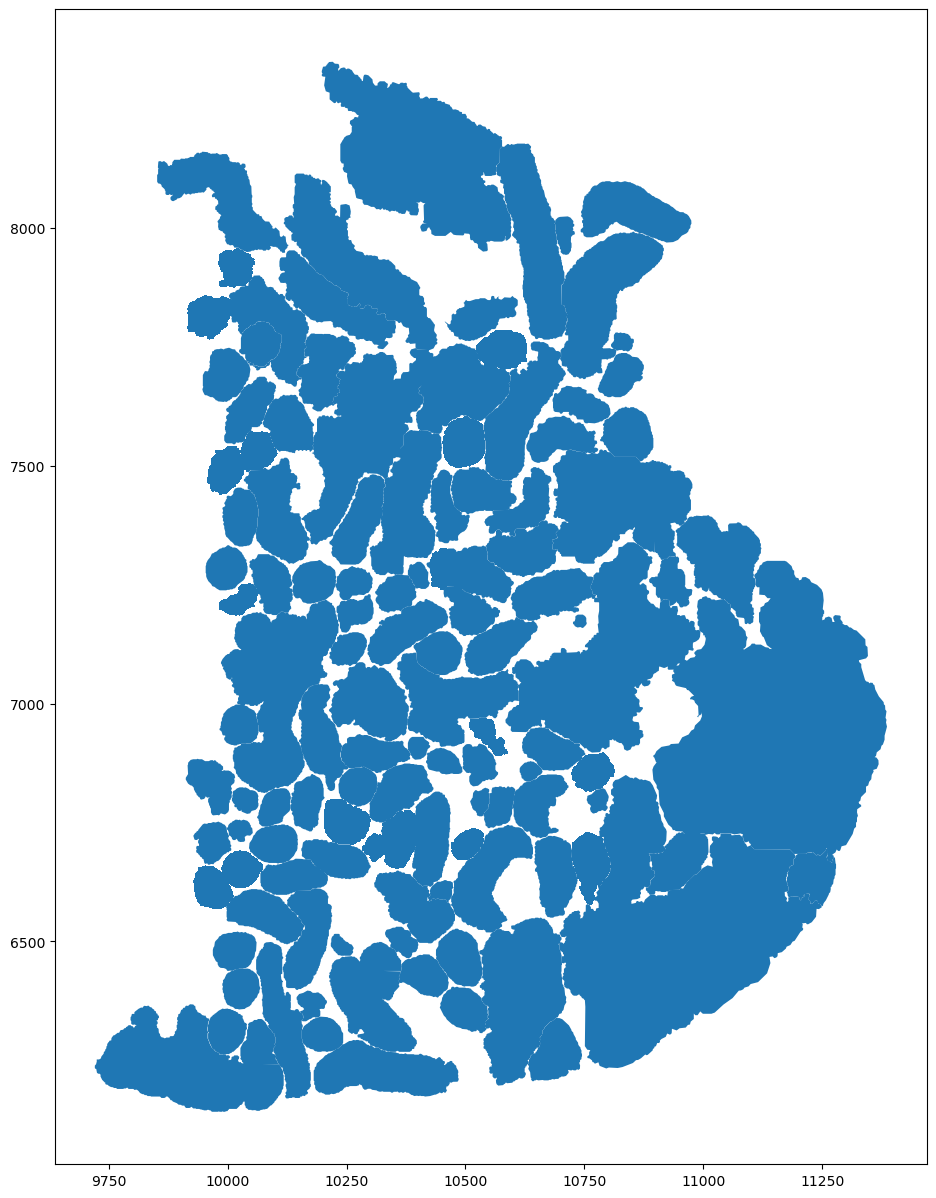

In [46]:
#Trying to focus on a zoomed in patch/tile
subset = gdf.cx[10000:12000, 6000:8000]
subset.plot(figsize=(15,15))

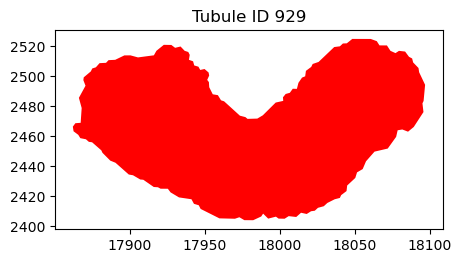

In [47]:
#Just focusing on one proximal tubule only
tubule = gdf[gdf["id"] == "929"] #Note geojson instance ID is stored as a string and not as an integer.
#print(tubule)
import matplotlib.pyplot as plt

ax = tubule.plot(figsize=(5,5), color="red")
ax.set_aspect("equal")
ax.set_title("Tubule ID 929")
plt.show()

In [48]:
#Loading the Ctrl_1A2 AnnData object (.h5ad format)
import scanpy as sc
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.head()


,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00000_02609-1,1,0,2609,1164.609932,6249.759373,<NA>
s_002um_00000_02610-1,1,0,2610,1164.662587,6245.220638,<NA>
s_002um_00000_02611-1,1,0,2611,1164.715242,6240.681902,<NA>
s_002um_00000_02612-1,1,0,2612,1164.767897,6236.143167,<NA>
s_002um_00000_02613-1,1,0,2613,1164.820552,6231.604433,<NA>


In the following lines, we will try to overlay a single proximal tubule with its Visium 2umx2um bins.

In [53]:
#Extract Tubule Polygon
tubule = gdf[gdf["id"] == "929"]
geom = tubule.geometry.iloc[0]

In [54]:
#Extract corresponding bin coordinates:
subset = ctrl1_data[ctrl1_data.obs['proximal_tubule_geojson_feature_index'].astype(str) == "929"]

x = subset.obs["pxl_col_in_fullres"]
y = subset.obs["pxl_row_in_fullres"]

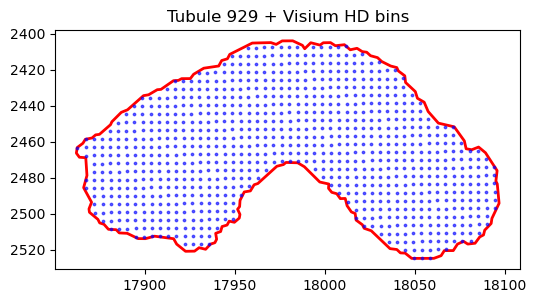

In [55]:
#Overlay/Plot together:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

# 1. plot tubule polygon
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# 2. plot bins inside tubule
ax.scatter(x, y, s=3, c="blue", alpha=0.6)

ax.set_aspect("equal")
ax.invert_yaxis()  # IMPORTANT for image coordinate systems
ax.set_title("Tubule 929 + Visium HD bins")

plt.show()